In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stylia
from stylia import ArticleColors, save_figure
from stylia import CategoricalPalette

stylia.set_format("slide")
stylia.set_style("ersilia")
pal = CategoricalPalette("ersilia")
nc = stylia.NamedColors()
plt.rcParams["figure.dpi"] = 300

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
pathogens = pd.read_csv(os.path.join(REPO_ROOT, "config", "pathogens.csv"))
code_to_name = dict(zip(pathogens["code"], pathogens["pathogen"]))
report = pd.read_csv(os.path.join(REPO_ROOT, "output", "results", "10_reports.csv"))

Pathogen: Acinetobacter baumannii
Pathogen: Candida albicans
Pathogen: Campylobacter
Pathogen: Escherichia coli
Pathogen: Enterococcus faecium
Pathogen: Enterobacter
Pathogen: Helicobacter pylori
Pathogen: Klebsiella pneumoniae
Pathogen: Mycobacterium tuberculosis
Pathogen: Neisseria gonorrhoeae
  [SKIP] file not found


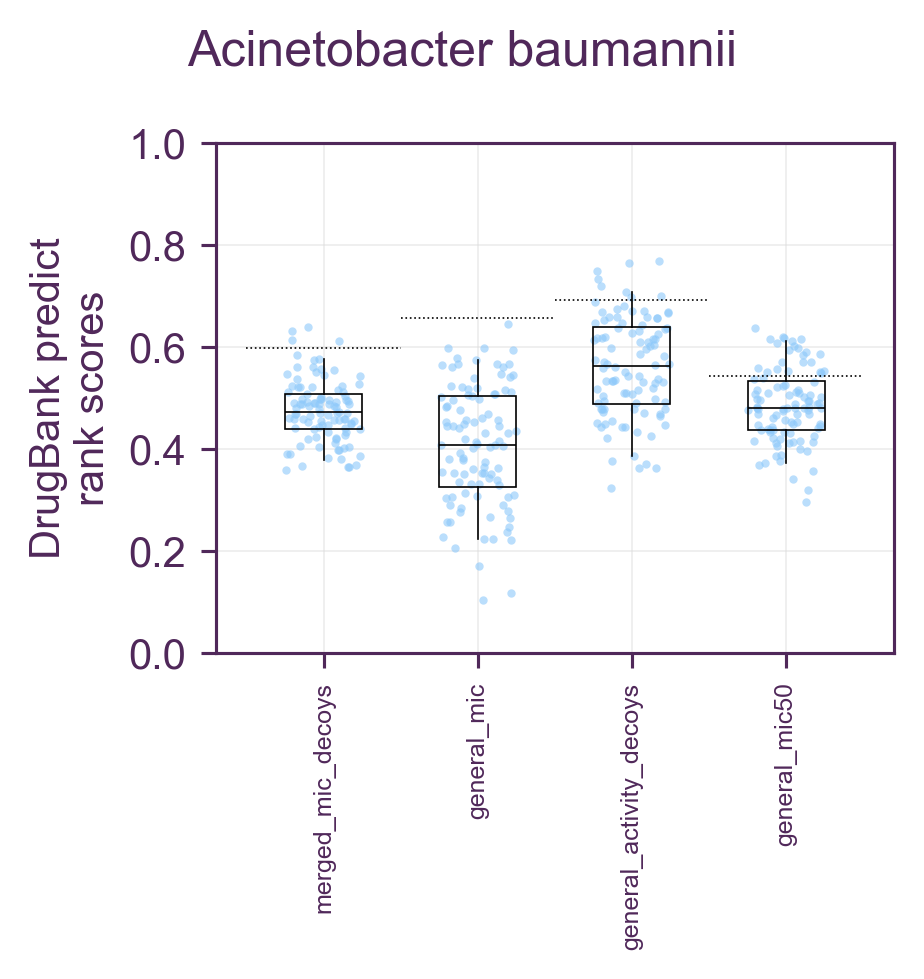

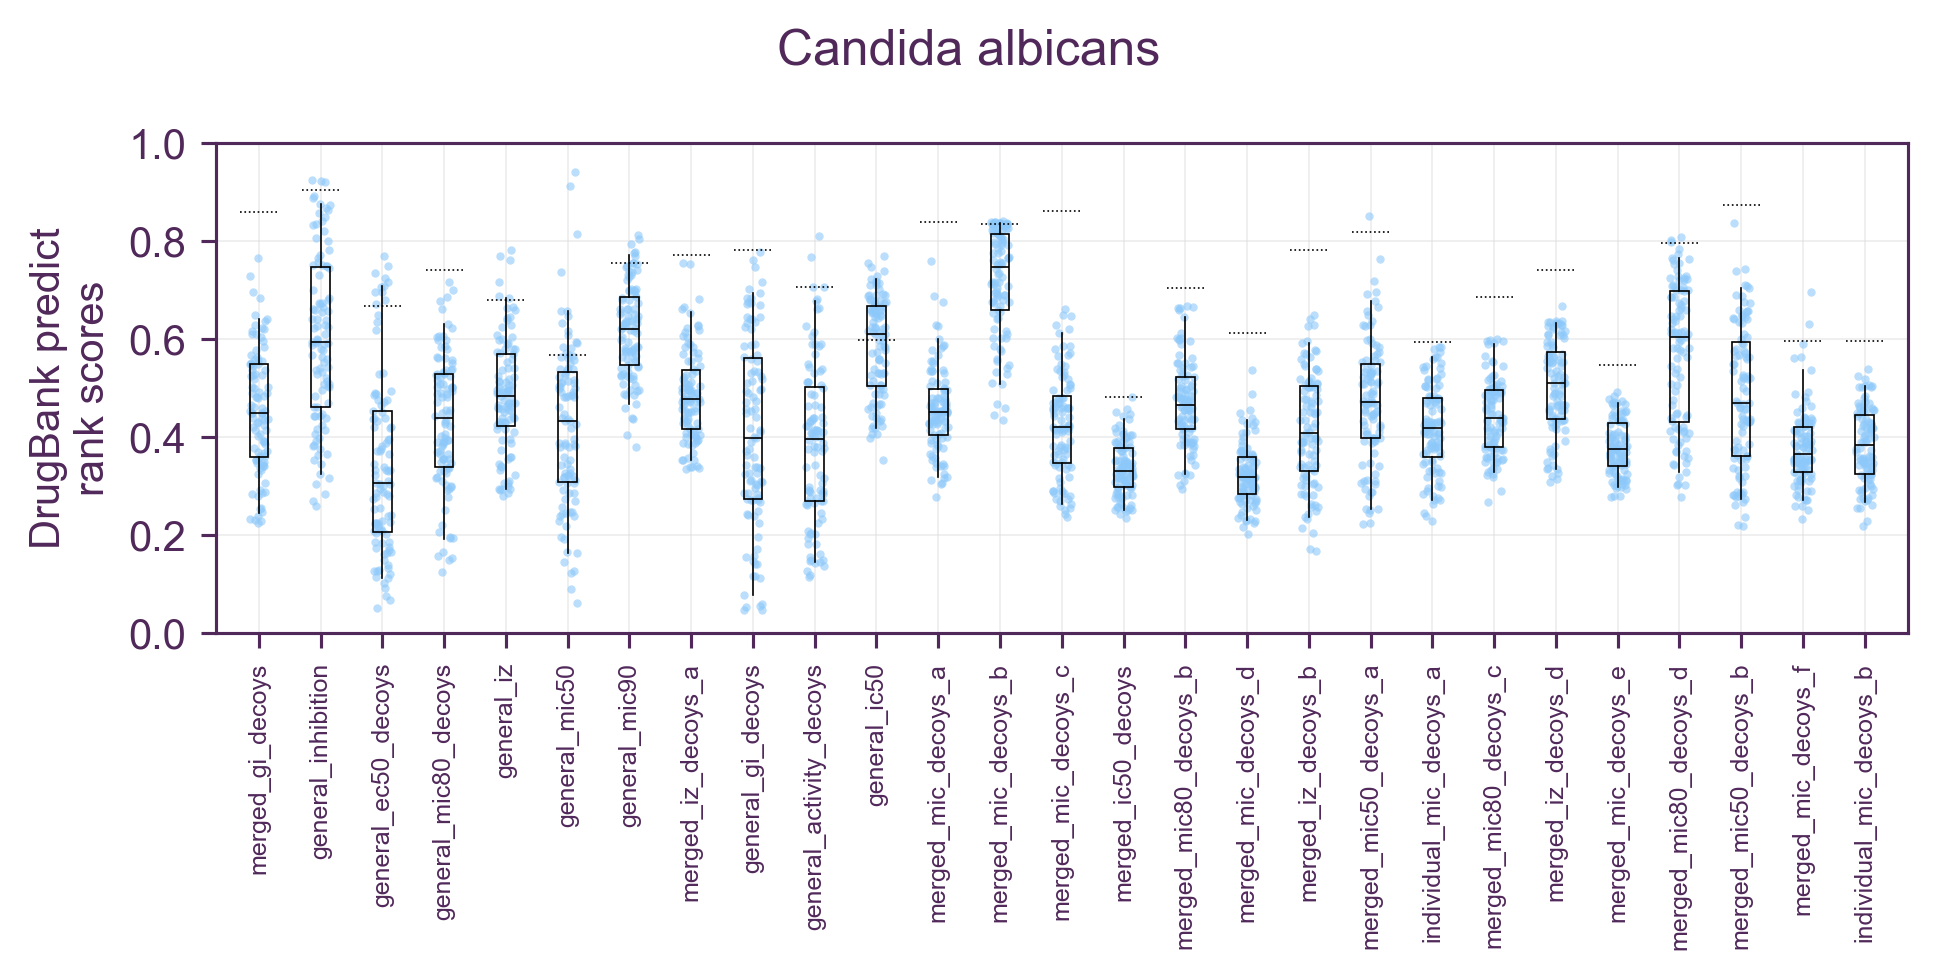

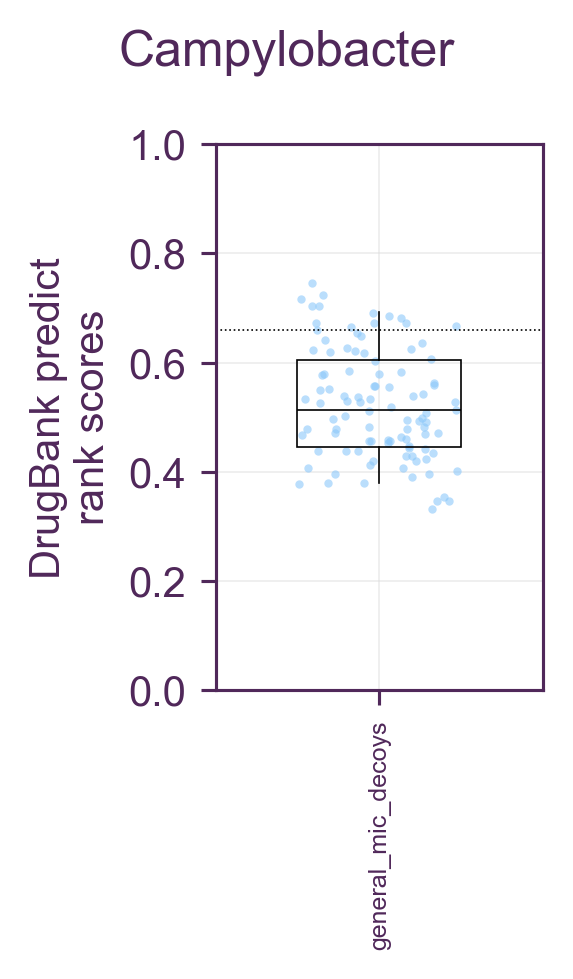

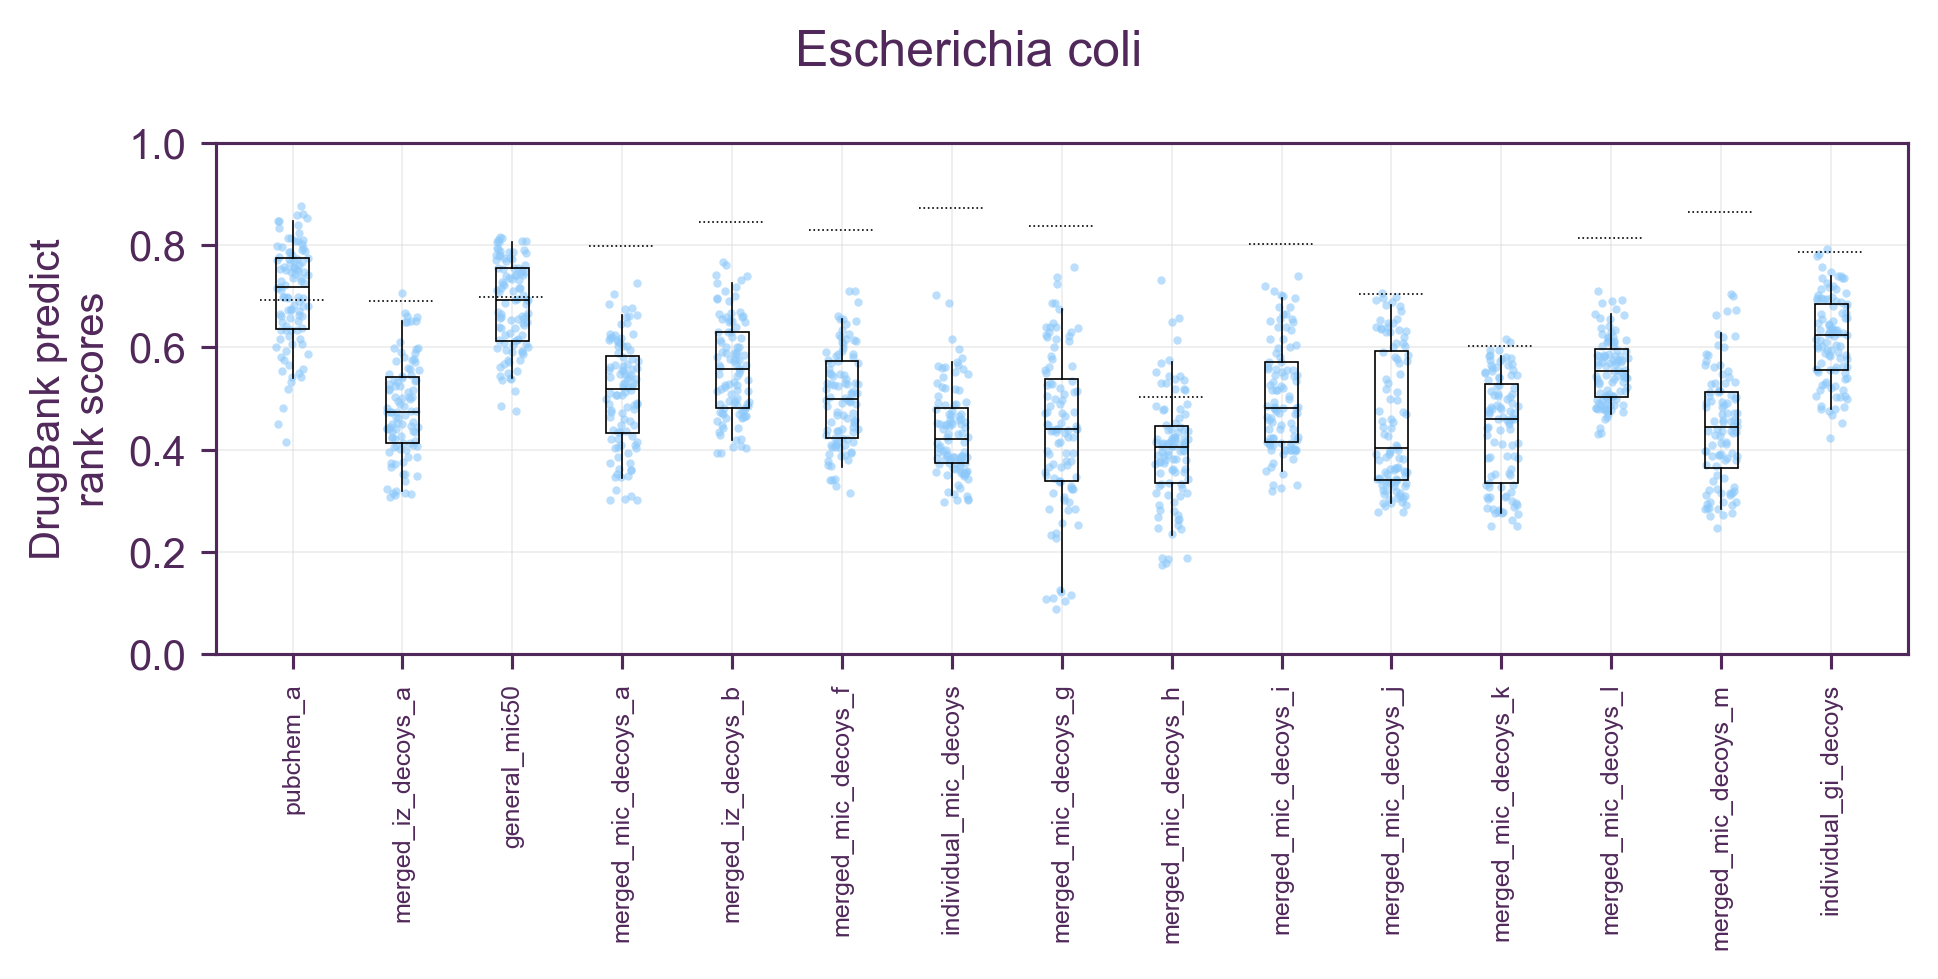

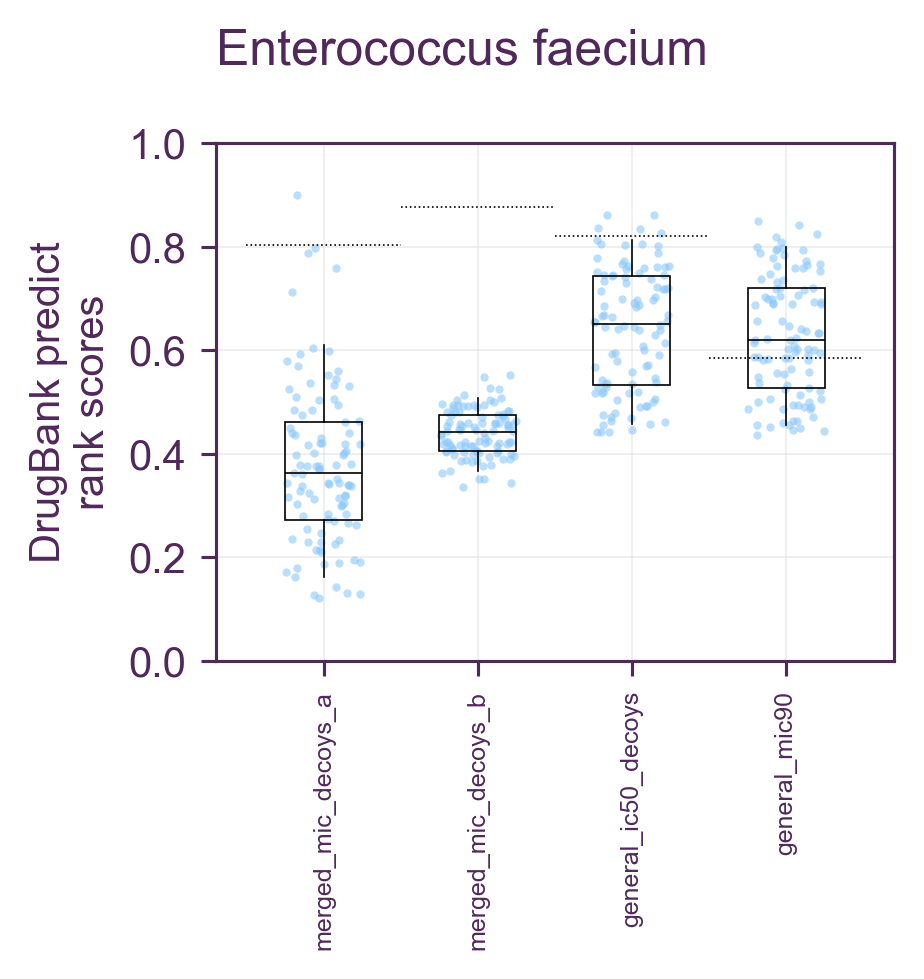

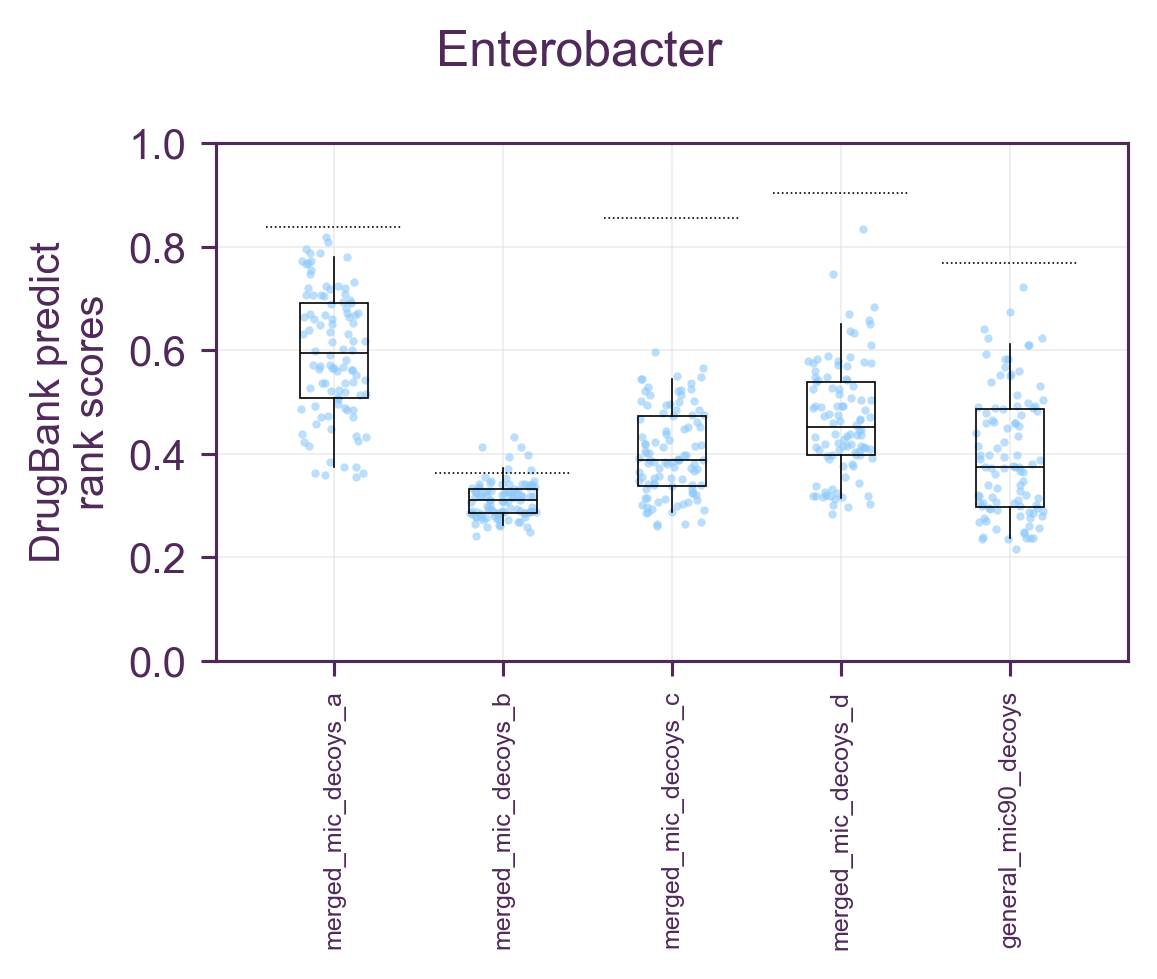

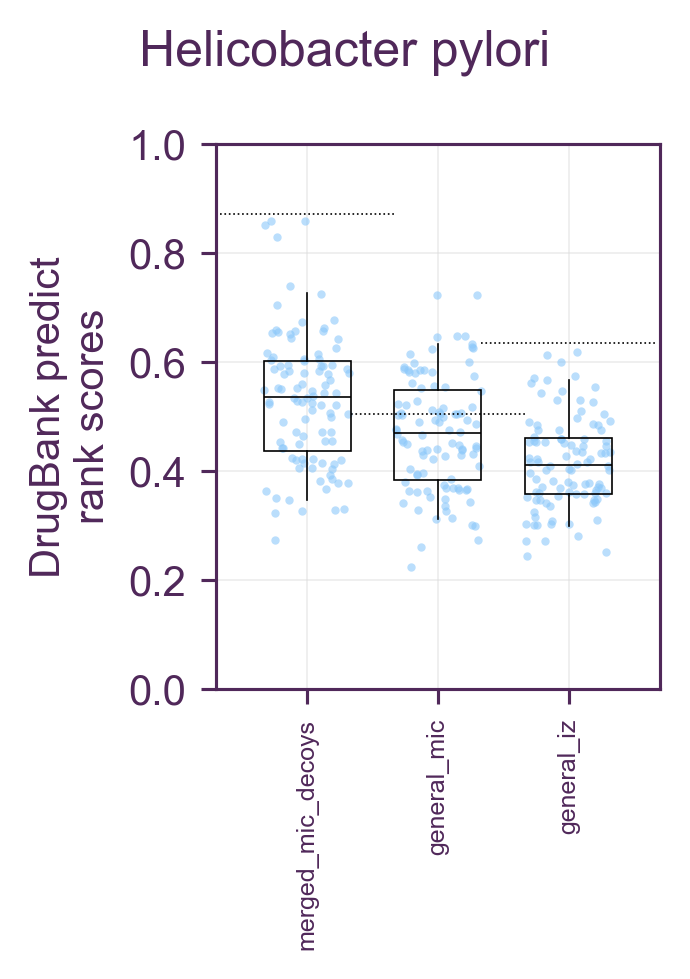

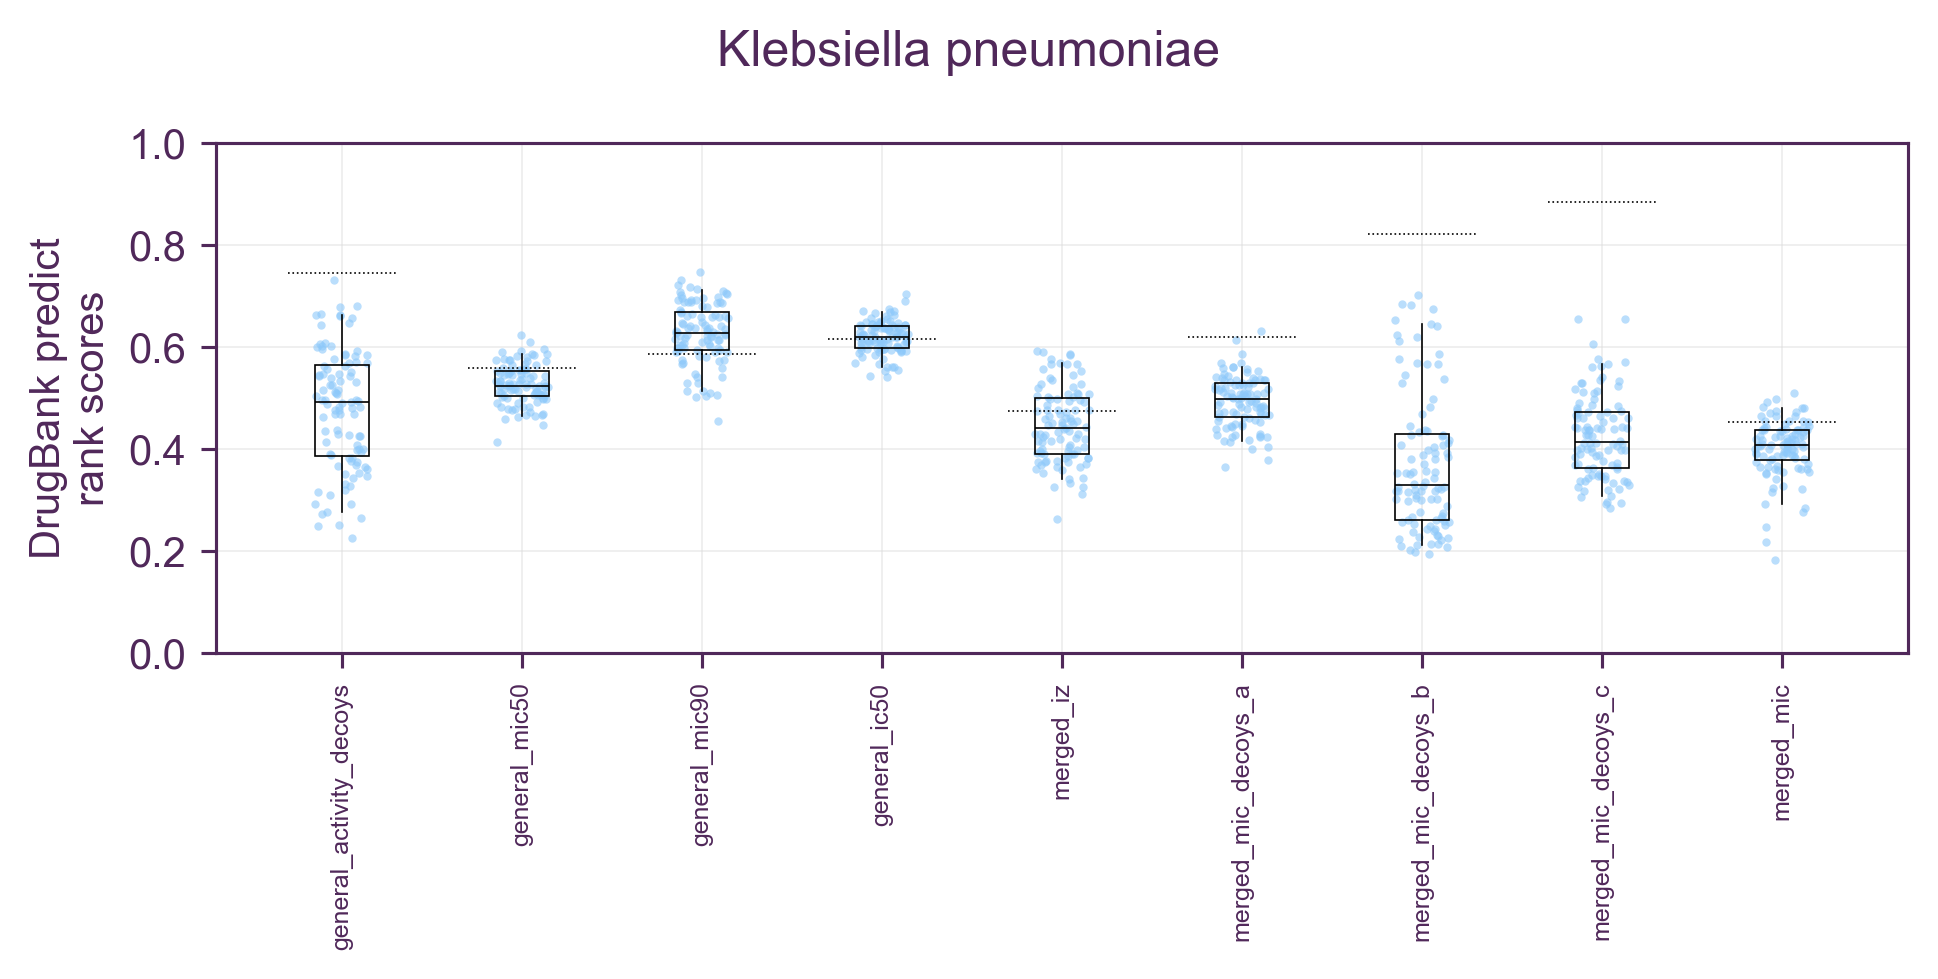

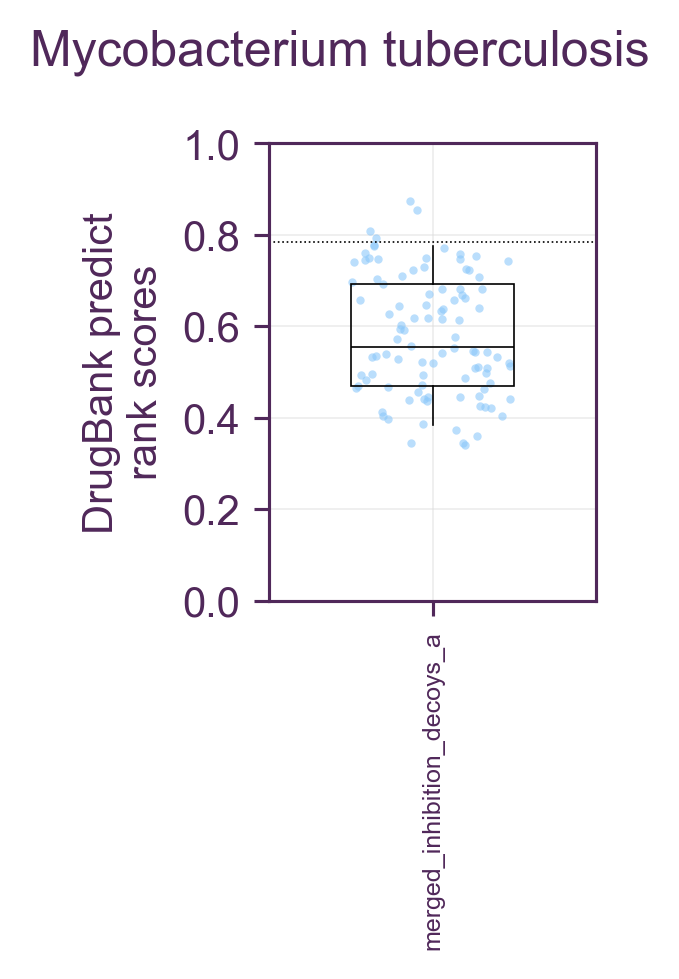

In [31]:
for pathogen in pathogens["code"]:

    print(f"Pathogen: {code_to_name[pathogen]}")

    src = os.path.join(REPO_ROOT, "output", "results", "12_drugbank", f"{pathogen}.csv")
    if not os.path.isfile(src):
        print("  [SKIP] file not found")
        break

    df = pd.read_csv(src)
    model_cols = [c for c in df.columns if c != "smiles"]
    N = len(model_cols)

    report_pathogen = report[report["pathogen"] == pathogen].set_index("model_name")

    # width scales with N, but never smaller than 0.2 to stay landscape
    # w scales wider when N is small so boxes fill the available space
    width = max(0.15, min(N * 0.06, 0.5))
    w     = min(0.35, max(0.15, 1.0 / N))

    fig, axs = stylia.create_figure(1, 1, width=width, height=0.25)
    fig.suptitle(f"{code_to_name[pathogen]}", fontsize=12)

    ax = axs.next()
    ax.set_ylabel("DrugBank predict\nrank scores")
    ax.set_ylim([0, 1])
    ax.set_xlim([-0.7, N - 0.3])

    rng = np.random.default_rng(42)
    for i, model in enumerate(model_cols):
        values = df[model].dropna().values
        x_jitter = [i + rng.uniform(-w, w) for _ in values]
        ax.scatter(x_jitter, values, color=pal.get(8)[4], s=4, alpha=0.6, lw=0)
        if model in report_pathogen.index:
            cutoff = report_pathogen.loc[model, "decision_cutoff_rank"]
            ax.plot([i - w * 2, i + w * 2], [cutoff, cutoff], lw=0.4, c='k', linestyle='dotted')
        stats = dict(
            med=np.median(values),
            q1=np.percentile(values, 25),
            q3=np.percentile(values, 75),
            whislo=np.percentile(values, 5),
            whishi=np.percentile(values, 95),
            fliers=[],
        )
        bp = ax.bxp([stats], positions=[i], widths=w * 2, patch_artist=True, showfliers=False)
        bp["boxes"][0].set_linewidth(0.4)
        bp["boxes"][0].set_facecolor("none")
        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                line.set_color("k")
                line.set_linewidth(0.4)
                if element == "caps":
                    line.set_linewidth(0)

    ax.set_xticks(range(N))
    ax.set_xlabel(None)
    ax.set_xticklabels(model_cols, rotation=90, size=6)